In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step - 1: Understanding Data :**

In [10]:
fraud_train = pd.read_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/raw/fraudTrain.csv')

In [11]:
fraud_test = pd.read_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/raw/fraudTest.csv')

In [12]:
df = pd.concat([fraud_train, fraud_test]).reset_index()

In [13]:
df

,index,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [ ]:
df.drop(df.columns[:2], axis=1, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

In [16]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
print(df.dtypes['trans_date_trans_time'])

datetime64[ns]


In [17]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [18]:
df.nunique()

Unnamed: 0               1296675
trans_date_trans_time    1819551
cc_num                       999
merchant                     693
category                      14
amt                        60616
first                        355
last                         486
gender                         2
street                       999
city                         906
state                         51
zip                          985
lat                          983
long                         983
city_pop                     891
job                          497
dob                          984
trans_num                1852394
unix_time                1819583
merch_lat                1754157
merch_long               1809753
is_fraud                       2
dtype: int64

# **Step - 2: Data pre-processing**

In [19]:
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
#deriving 'day of the week'
df['trans_day_of_week'] = df['trans_date_trans_time'].dt.day_name()
#deriving 'year_month'
df['trans_year_month'] = df['trans_date_trans_time'].dt.to_period('M')

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,Tuesday,2019-01
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,Tuesday,2019-01
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,Tuesday,2019-01
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,Tuesday,2019-01
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,Tuesday,2019-01


In [20]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = np.round((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25)

In [21]:
df['age']

0          31.0
1          41.0
2          57.0
3          52.0
4          33.0
           ... 
1852389    55.0
1852390    21.0
1852391    39.0
1852392    55.0
1852393    28.0
Name: age, Length: 1852394, dtype: float64

In [22]:
df.drop(['trans_date_trans_time','first', 'last', 'dob'] , axis=1, inplace=True)
df.head()

,Unnamed: 0,cc_num,merchant,category,amt,gender,street,city,state,zip,...,job,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month,age
0,0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,"Psychologist, counselling",0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,Tuesday,2019-01,31.0
1,1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,Special educational needs teacher,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,Tuesday,2019-01,41.0
2,2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,Nature conservation officer,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,Tuesday,2019-01,57.0
3,3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,Patent attorney,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,Tuesday,2019-01,52.0
4,4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,Dance movement psychotherapist,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,Tuesday,2019-01,33.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column             Dtype    
---  ------             -----    
 0   Unnamed: 0         int64    
 1   cc_num             int64    
 2   merchant           object   
 3   category           object   
 4   amt                float64  
 5   gender             object   
 6   street             object   
 7   city               object   
 8   state              object   
 9   zip                int64    
 10  lat                float64  
 11  long               float64  
 12  city_pop           int64    
 13  job                object   
 14  trans_num          object   
 15  unix_time          int64    
 16  merch_lat          float64  
 17  merch_long         float64  
 18  is_fraud           int64    
 19  trans_hour         int32    
 20  trans_day_of_week  object   
 21  trans_year_month   period[M]
 22  age                float64  
dtypes: float64(6), int32(1), int64(6

In [24]:
df_org = df.copy()

# **Step - 3: Exploratory Data Analysis [EDA]**

In [25]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,age
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,5.371934e+05,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03,1.280612e+01,4.626375e+01
std,3.669110e+05,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02,6.815753e+00,1.741216e+01
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00,0.000000e+00,1.400000e+01
25%,2.315490e+05,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00,7.000000e+00,3.300000e+01
50%,4.630980e+05,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00,1.400000e+01,4.400000e+01
75%,8.335758e+05,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00,1.900000e+01,5.700000e+01
max,1.296674e+06,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00,2.300000e+01,9.600000e+01


In [26]:
100*df.is_fraud.value_counts(normalize=True)

is_fraud
0    99.478999
1     0.521001
Name: proportion, dtype: float64

In [27]:
pd.concat(
    [df['amt'].describe(percentiles = [0.5,0.95,0.999]).reset_index().rename(columns={'index': 'Row Type', 'amt':'Overall Amt Distribution'}),
     df.loc[df['is_fraud']==0,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Non-Fraud Amt Distribution'}),
     df.loc[df['is_fraud']==1,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Fraud Amt Distribution'})], axis=1)

,Row Type,Overall Amt Distribution,Non-Fraud Amt Distribution,Fraud Amt Distribution
0,count,1.852394e+06,1.842743e+06,9651.000000
1,mean,7.006357e+01,6.765128e+01,530.661412
2,std,1.592540e+02,1.535481e+02,391.028873
3,min,1.000000e+00,1.000000e+00,1.060000
4,50%,4.745000e+01,4.724000e+01,390.000000
5,95%,1.953400e+02,1.895900e+02,1084.090000
6,99.9%,1.517241e+03,1.519623e+03,1293.127000
7,max,2.894890e+04,2.894890e+04,1376.040000


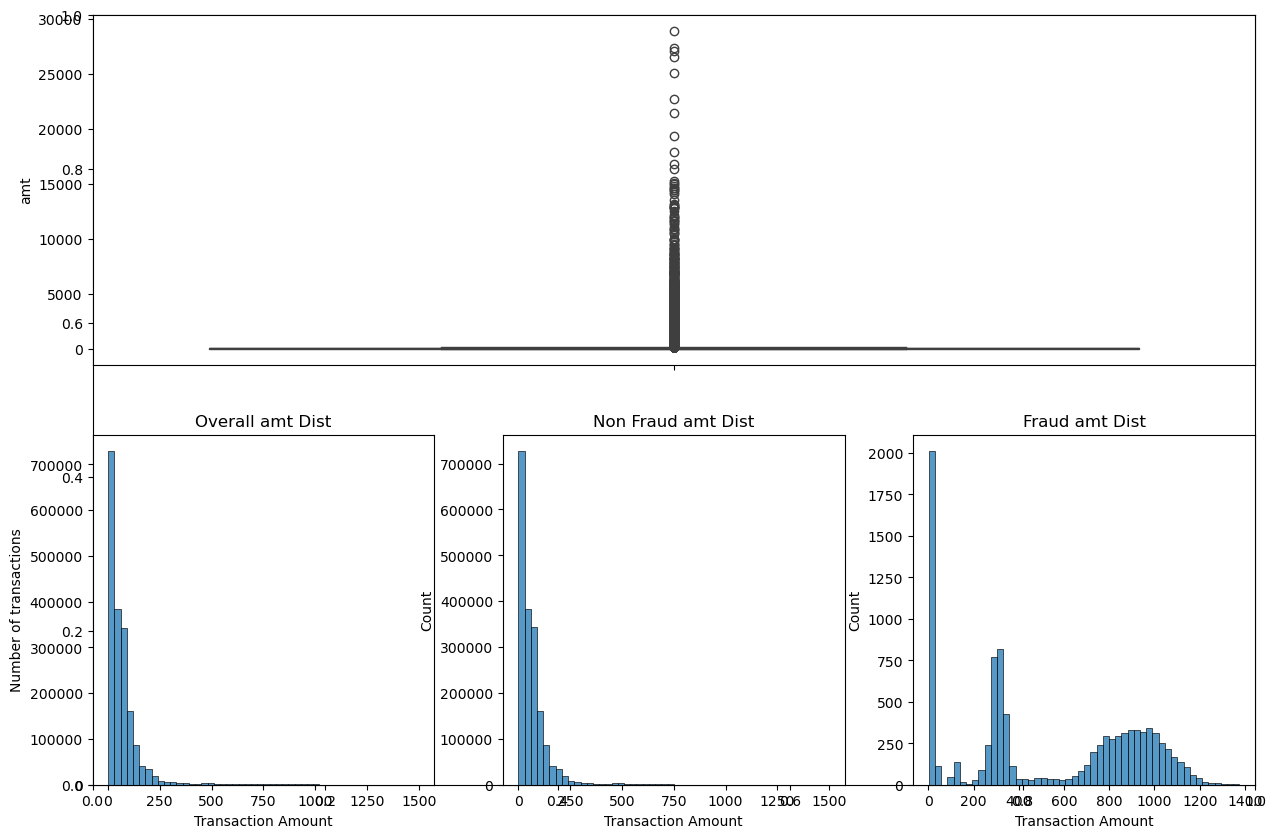

In [28]:
fig = plt.subplots(figsize=(15,10))
plots = []
plots.append(sns.boxplot(df.amt, ax=plt.subplot(211)))
plots.append(sns.histplot(df[df.amt <= 1500].amt, bins=50, ax=plt.subplot(234)))
plots.append(sns.histplot(df[(df.is_fraud==0) & (df.amt<=1500)].amt, bins=50, ax=plt.subplot(235)))
plots.append(sns.histplot(df[(df.is_fraud==1) & (df.amt<=1500)].amt, bins=50, ax=plt.subplot(236)))
plots[1].set_title('Overall amt Dist')
plots[2].set_title('Non Fraud amt Dist')
plots[3].set_title('Fraud amt Dist')
plots[1].set_xlabel('Transaction Amount')
plots[2].set_xlabel('Transaction Amount')
plots[3].set_xlabel('Transaction Amount')
plots[1].set_ylabel('Number of transactions')

plt.show()

##### **Observation ('amt' Feature):**
- The 'amt' feature shows significant outliers, indicating high variance.
- The overall and non-fraud amount distributions are similar, but the fraud amount mean is higher.
- Skewness in the data is evident.

##### **Inference:**
- Despite a higher mean for fraud amounts, they are evenly distributed and often involve smaller values compared to non-fraud transactions.
- Fraud transactions typically occur around 200, **sometimes ranging up to** 400.
- Closer monitoring of small-amount transactions can help detect and prevent credit card fraud.

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\3734955394.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)  # Rotate labels for better readability
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\3734955394.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)


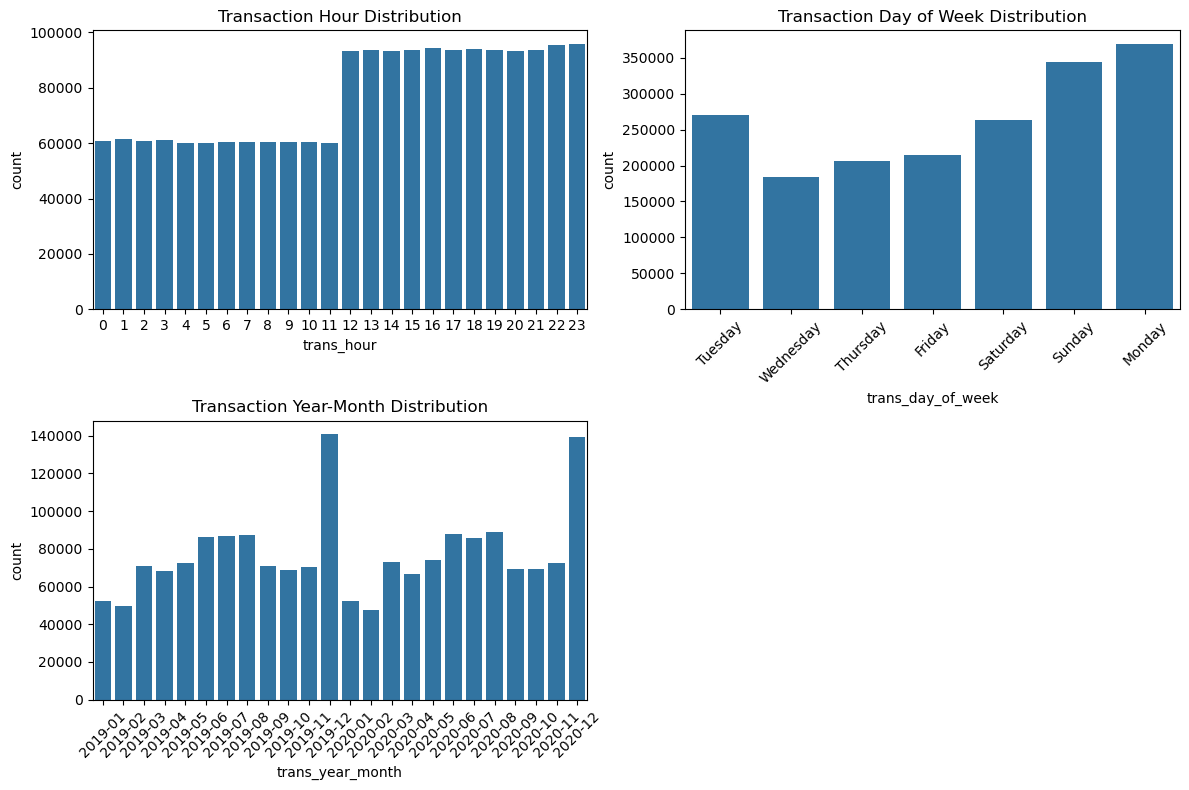

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  \\
sns.countplot(x=df['trans_hour'], ax=axes[0, 0])
axes[0, 0].set_title("Transaction Hour Distribution")

sns.countplot(x=df['trans_day_of_week'], ax=axes[0, 1])
axes[0, 1].set_title("Transaction Day of Week Distribution")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)  

sns.countplot(x=df['trans_year_month'], ax=axes[1, 0])
axes[1, 0].set_title("Transaction Year-Month Distribution")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

fig.delaxes(axes[1, 1])

plt.tight_layout()  
plt.show()


In [31]:
df_timeline01 = df.groupby(df['trans_year_month'])[['trans_num','cc_num']].nunique().reset_index()
df_timeline01.columns = ['year_month','num_of_transactions','customers']
df_timeline01

,year_month,num_of_transactions,customers
0,2019-01,52525,913
1,2019-02,49866,918
2,2019-03,70939,916
3,2019-04,68078,913
4,2019-05,72532,910
5,2019-06,86064,908
6,2019-07,86596,910
7,2019-08,87359,911
8,2019-09,70652,913
9,2019-10,68758,912


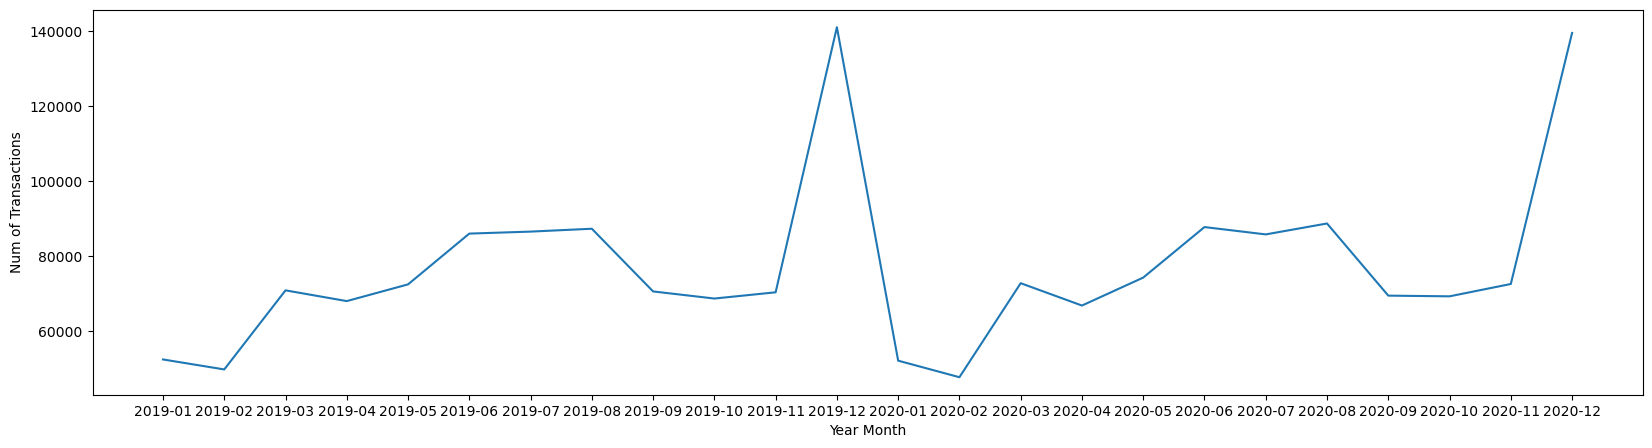

In [32]:
x = np.arange(0,len(df_timeline01),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,df_timeline01['num_of_transactions'])
ax.set_xticks(x)
ax.set_xticklabels(df_timeline01['year_month'])

ax.set_xlabel('Year Month')
ax.set_ylabel('Num of Transactions')
plt.show()

In [33]:
df_fraud_transactions = df[df['is_fraud']==1]

df_timeline02 = df_fraud_transactions.groupby(df_fraud_transactions['trans_year_month'])[['trans_num','cc_num']].nunique().reset_index()
df_timeline02.columns = ['year_month','num_of_fraud_transactions','fraud_customers']
df_timeline02

,year_month,num_of_fraud_transactions,fraud_customers
0,2019-01,506,50
1,2019-02,517,53
2,2019-03,494,49
3,2019-04,376,41
4,2019-05,408,42
5,2019-06,354,35
6,2019-07,331,36
7,2019-08,382,39
8,2019-09,418,44
9,2019-10,454,50


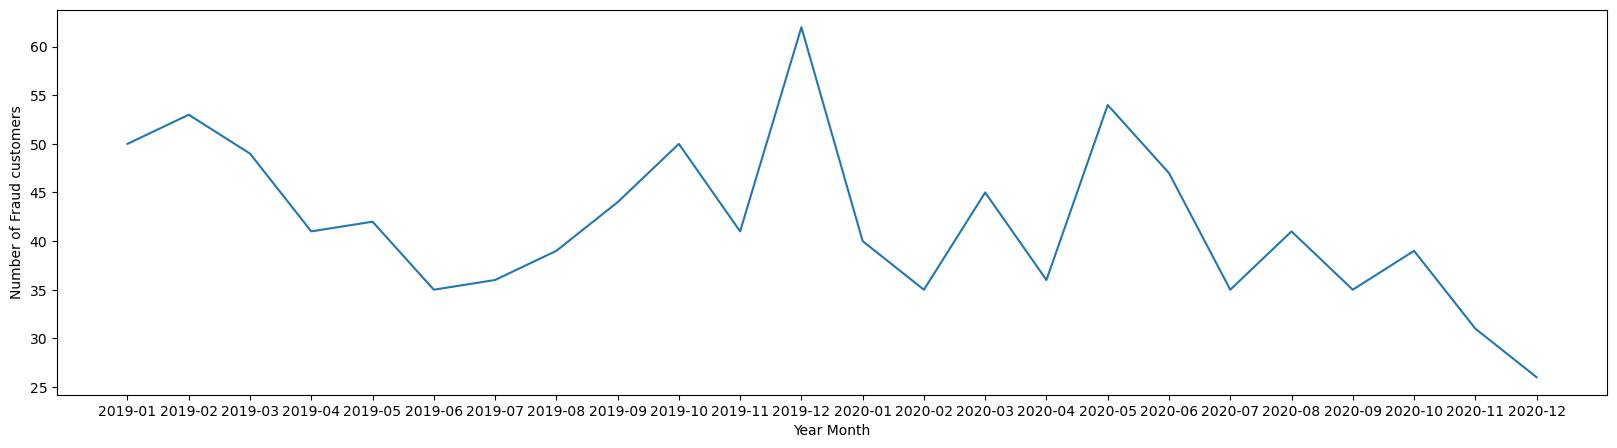

In [34]:
x = np.arange(0,len(df_timeline02),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,df_timeline02['fraud_customers'])
ax.set_xticks(x)
ax.set_xticklabels(df_timeline02['year_month'])

ax.set_xlabel('Year Month')
ax.set_ylabel('Number of Fraud customers')
plt.show()

#### **Observation (Time Data):**
- Most transactions occur in the afternoon (after 12 PM) and on Sundays and Mondays.
- Peak transaction months include January, February, October, December 2019, and May 2020.
- Fraud cases and transactions spike in December, coinciding with the holiday season.

#### **Inference:**
- Surveillance can be heightened for afternoon transactions (after 12 PM) to curb fraud.
- Holiday seasons, especially December, should be closely monitored due to increased transaction volumes and fraud risks.
- Merchants in shopping and recreational sectors should be educated about fraudulent practices, as these activities peak during holidays.

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  pl

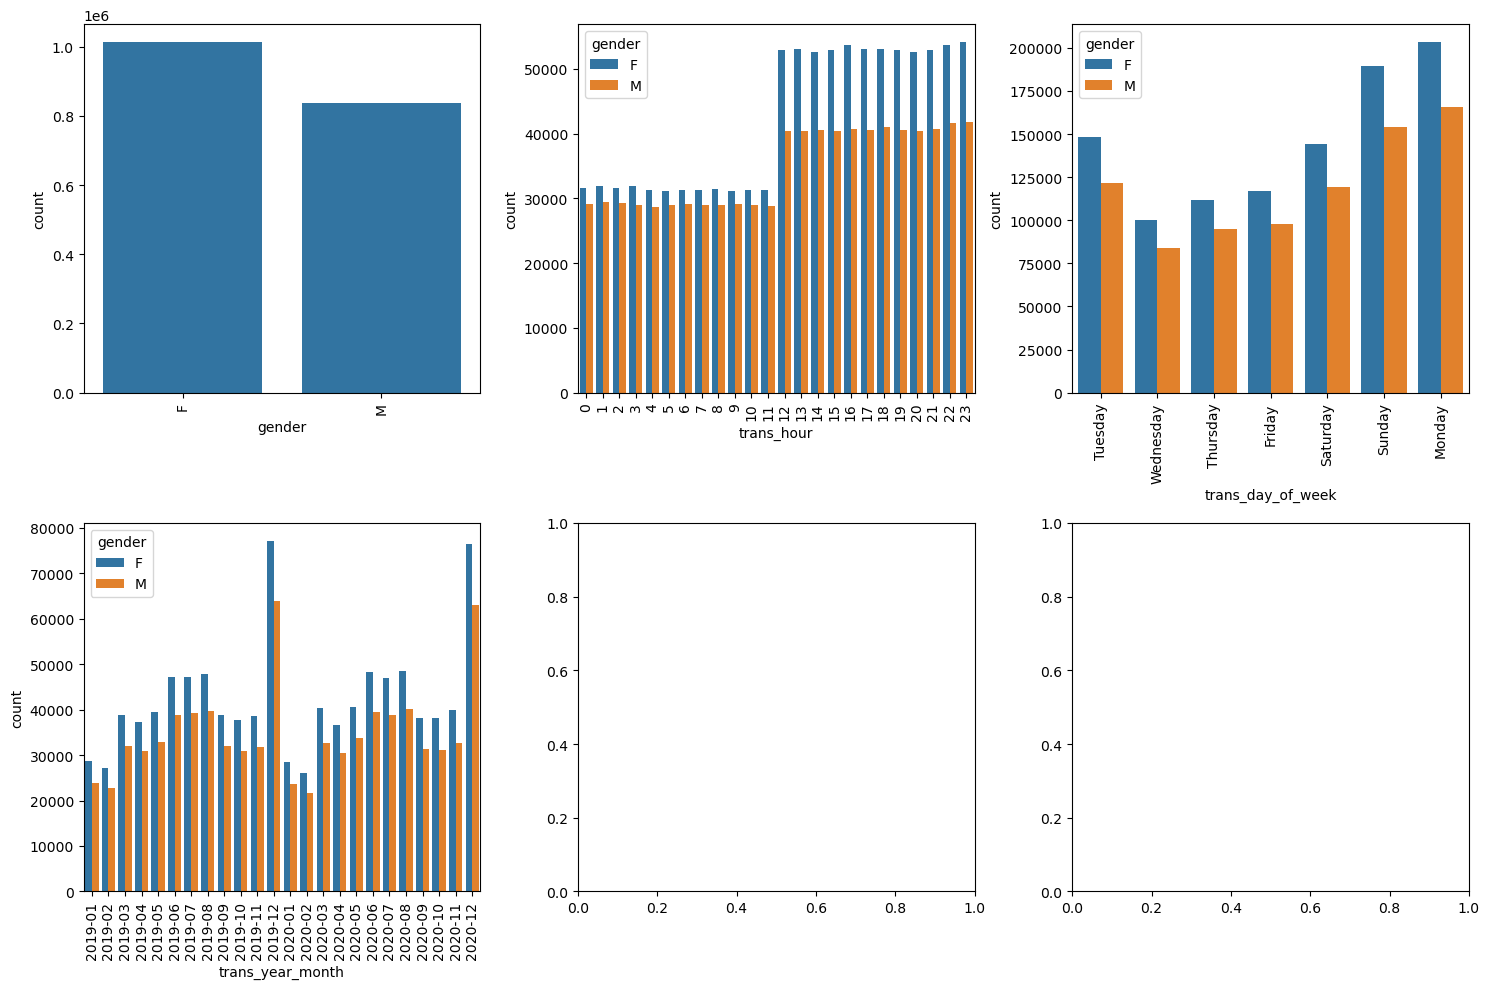

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Create all subplots in a grid
axes = axes.flatten()  # Flatten for easy access

# Create a list to store plots
plots = []

# Gender demographic with respect to transactions
plots.append(sns.countplot(data=df, x='gender', ax=axes[0]))

# Transactions over time with respect to gender
plots.append(sns.countplot(data=df, x='trans_hour', hue='gender', ax=axes[1]))
plots.append(sns.countplot(data=df, x='trans_day_of_week', hue='gender', ax=axes[2]))
plots.append(sns.countplot(data=df, x='trans_year_month', hue='gender', ax=axes[3]))

# Rotate x-axis labels for all plots
for plot in plots:
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


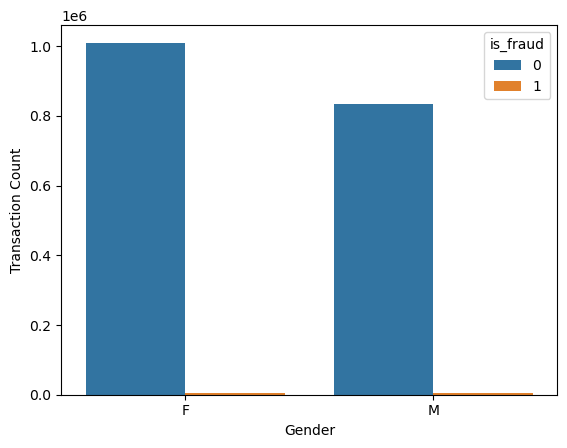

In [37]:
#creating the 'gender' distributed dataframe
df_gender = df[['gender','trans_num']].groupby(['gender']).count().reset_index()
df_gender.columns = ['Gender', 'gender_count']

#creating gender-fraud distribution
df_fraud_gender = df[['gender','trans_num', 'is_fraud']].groupby(['gender','is_fraud']).count().reset_index()
df_fraud_gender.columns = ['Gender', 'is_fraud', 'Transaction Count']

df_fraud_gender = df_fraud_gender.merge(df_gender[['Gender', 'gender_count']], how='inner', on='Gender')

df_fraud_gender['Transaction percentage'] = (df_fraud_gender['Transaction Count']/df_fraud_gender['gender_count'])*100

df_fraud_gender
sns.barplot(data=df_fraud_gender, y='Transaction Count', x='Gender', hue='is_fraud')
plt.show()

##### **Observation:**
- Women contribute the most to transaction frequencies.
- Fraud involvement is 0.52% for women and 0.64% for men relative to their transaction volumes.

#### **Inference:**
- Women, being more active in transactions, may be more prone to fraud.
- While all sexes should be educated about fraud prevention, women, due to their higher transaction activity, should be particularly vigilant.
- Men show a slightly higher tendency to be involved in fraud, though both sexes are nearly equally represented in fraudulent transactions.

In [39]:
#let us first bin the age feature
for i in range(len(df.age)):
  if df.age[i] <= 30:
    df.age[i] = '< 30'
  elif df.age[i] > 30 and df.age[i] <= 45:
    df.age[i] = '30-45'
  elif df.age[i] > 45 and df.age[i] <= 60:
    df.age[i] = '46-60'
  elif df.age[i] > 60 and df.age[i] <= 75:
    df.age[i] = '61-75'
  else:
    df.age[i] = '> 75'

df.age.head()

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\3825395916.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.age[i] = '30-45'
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\3825395916.py:6: SettingWithCopyWarning: 


0    30-45
1    30-45
2    46-60
3    46-60
4    30-45
Name: age, dtype: object

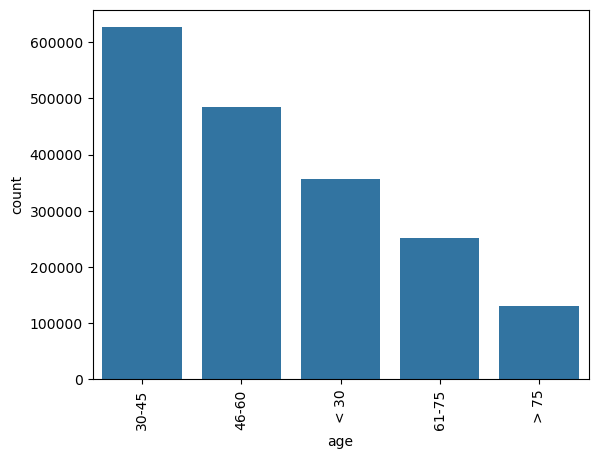

In [40]:
plot = sns.countplot(data=df, x='age') 
plt.xticks(rotation=90) 
plt.show()

###### **Observation (Age Groups):**
- The 30-45 age group accounts for the highest number of transactions, followed by the 46-60 age group.
- The >75 age group, while making fewer transactions, has the highest fraud rate (~1% of their transactions are fraudulent).

###### **Inference:**
- Individuals aged >75 are most vulnerable to fraud and should be monitored more closely. They also need targeted education to raise awareness about fraudulent practices.
- Fraudsters may target older individuals, exploiting potential gaps in their financial knowledge or awareness.

In [42]:
df.state.nunique()

51

since there are a lot of categories in the 'state' variable of the data, we will now only look at the top 20 states wherein the transaction frequencies are the highest.

In [44]:
high_trans_states = df.state.value_counts().head(20).index.tolist()
print(high_trans_states)

['TX', 'NY', 'PA', 'CA', 'OH', 'MI', 'IL', 'FL', 'AL', 'MO', 'MN', 'AR', 'NC', 'VA', 'WI', 'SC', 'KY', 'IN', 'IA', 'OK']


In [45]:
100*df[df.state.isin(high_trans_states)].state.value_counts(normalize=True)

state
TX    10.961858
NY     9.677414
PA     9.252292
CA     6.523111
OH     5.399284
MI     5.334292
IL     5.041503
FL     4.925052
AL     4.742394
MO     4.449281
MN     3.681776
AR     3.615163
NC     3.495470
VA     3.383801
WI     3.382342
SC     3.381775
KY     3.320997
IN     3.204141
IA     3.144578
OK     3.083476
Name: proportion, dtype: float64

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2094744530.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


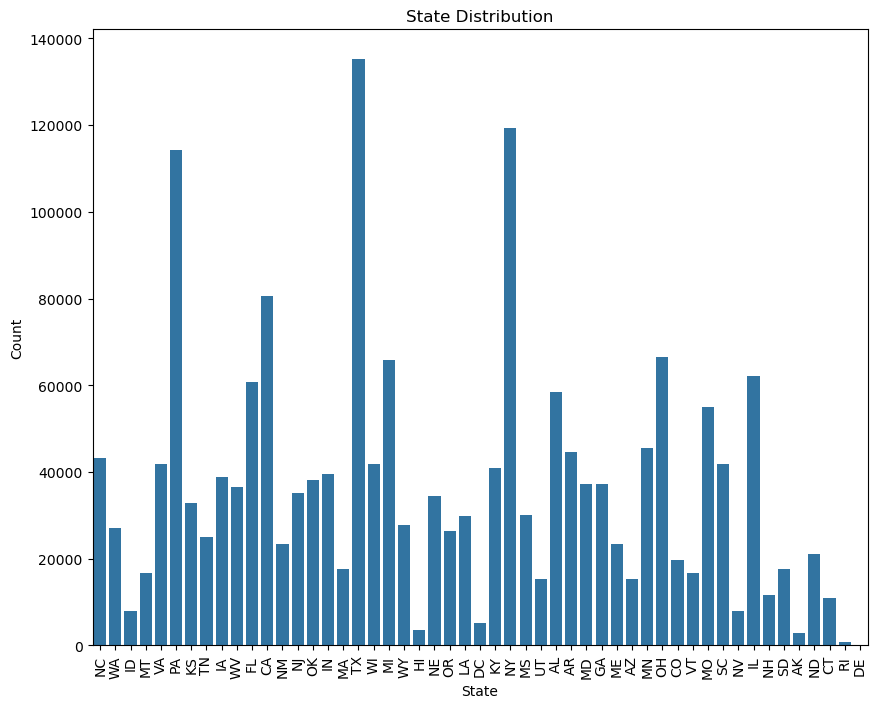

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x=df['state'], ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.xlabel("State")
plt.ylabel("Count")
plt.title("State Distribution")
plt.show()

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\1212158977.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


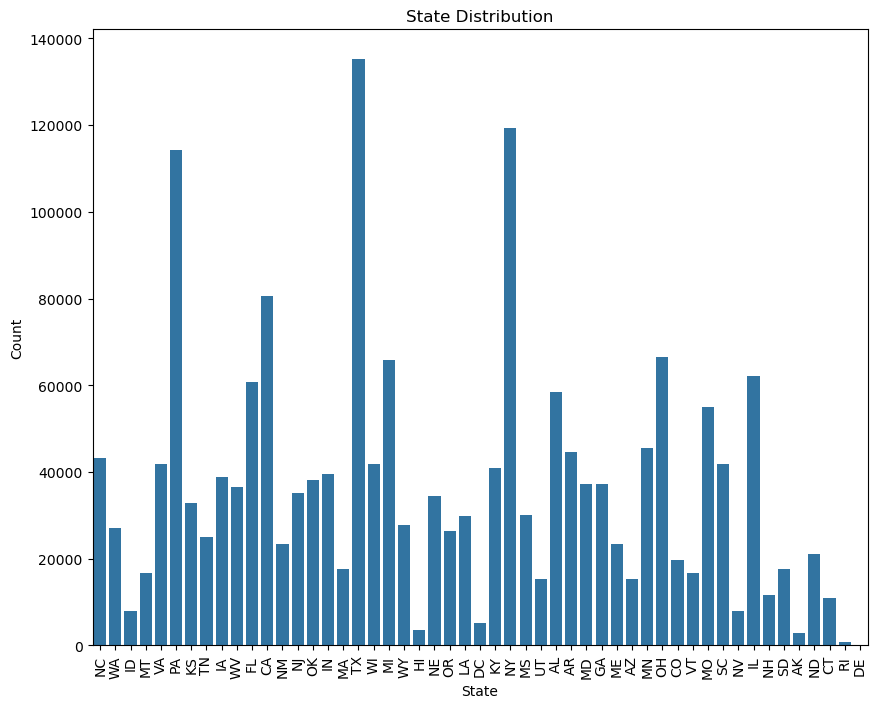

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x=df['state'], ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.xlabel("State")
plt.ylabel("Count")
plt.title("State Distribution")
plt.show()

In [48]:
#constructing the state-transaction count distribution
df_state = df[['state','trans_num']].groupby(['state']).count().reset_index()
df_state.columns = ['state', 'state_count']

#creating the state-fraud distribution
df_fraud_state = df[['state', 'trans_num', 'is_fraud']].groupby(['state','is_fraud']).count().reset_index()
df_fraud_state.columns = ['state', 'is_fraud', 'Transaction count']

df_fraud_state = df_fraud_state.merge(df_state[['state', 'state_count']], how='inner', on='state')

df_fraud_state['Transaction percentage'] = (df_fraud_state['Transaction count']/df_fraud_state['state_count'])*100

#viewing the top 20 states with high fraudulent transactions
df_fraud_state[df_fraud_state['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,state,is_fraud,Transaction count,state_count,Transaction percentage
16,DE,1,9,9,100.000000
78,RI,1,15,745,2.013423
1,AK,1,50,2963,1.687479
74,OR,1,197,26408,0.745986
60,NH,1,79,11727,0.673659
90,VA,1,273,41756,0.653798
84,TN,1,159,24913,0.638221
58,NE,1,216,34425,0.627451
46,MN,1,280,45433,0.616292
68,NY,1,730,119419,0.611293


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\1843818241.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


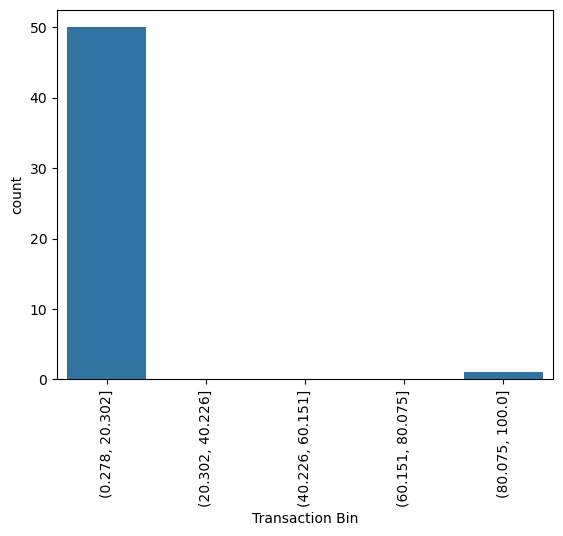

In [49]:
binned_data = pd.cut(df_fraud_state[df_fraud_state.is_fraud == 1]['Transaction percentage'], bins=5)

binned_df = pd.DataFrame({'Transaction Bin': binned_data})

plot = sns.countplot(data=binned_df, x='Transaction Bin')
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

plt.show()

In [50]:
#states with more than 75% fraudulent transactions
print('state with more than 75% fraudulent transactions:\n')
print(df_fraud_state.loc[(df_fraud_state.is_fraud == 1) & (df_fraud_state['Transaction percentage'] >= 75)].state)

state with more than 75% fraudulent transactions:

16    DE
Name: state, dtype: object


#### **Observation (State Feature):**
- States like 'PA', 'TX', and 'NY' have the highest transaction volumes, followed by 'FL', 'CA', 'MI', 'AL', 'OH', and 'IL'.
- These states, with high transaction activity, are more prone to fraud through methods like ATM and POS tampering.
- All top 20 states with high transaction volumes have a fraud rate of ~0.5%, with 'DE' being the most fraudulent state.

#### **Inference:**
- To reduce fraud, transaction monitoring should be intensified in high-transaction states.
- Residents in these areas should be educated about fraudulent practices and encouraged to follow best practices to minimize credit card fraud risks.

In [52]:
print('number of cities: ',df.city.nunique())
print('number of zip codes: ',df.zip.nunique())

number of cities:  906
number of zip codes:  985


- Plotting a feature with a high number of unique values is challenging.
- Cities or zip codes with high transaction frequencies are more likely to experience fraud.
- To simplify visualization, we will focus on the top 20 cities and top 20 zip codes with the highest transaction frequencies.

In [54]:
high_trans_cities = df.city.value_counts().head(20).index.tolist()
high_trans_zips = df.zip.value_counts().head(20).index.tolist()
print('high frequencies cities: ', high_trans_cities)
print('high frequencies zip codes: ', high_trans_zips)

high frequencies cities:  ['Birmingham', 'San Antonio', 'Utica', 'Phoenix', 'Meridian', 'Warren', 'Conway', 'Cleveland', 'Thomas', 'Houston', 'Arcadia', 'Naples', 'Brandon', 'Fulton', 'Indianapolis', 'Burbank', 'Dallas', 'Washington', 'Detroit', 'Hudson']
high frequencies zip codes:  [82514, 73754, 48088, 34112, 61454, 16114, 89512, 72476, 84540, 72042, 33872, 46346, 12419, 29438, 15484, 5461, 85173, 6024, 7060, 58569]


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\4065395168.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\4065395168.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


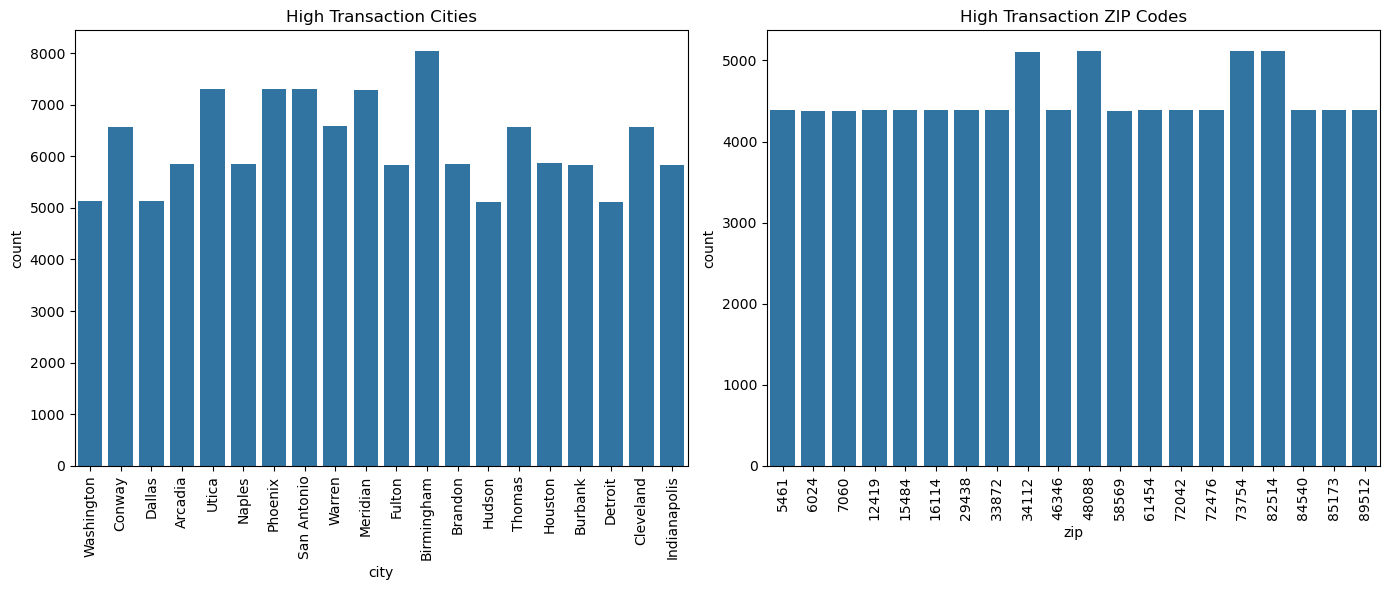

In [55]:
filtered_cities = df[df.city.isin(high_trans_cities)]
filtered_zips = df[df.zip.isin(high_trans_zips)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x="city", data=filtered_cities, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_title("High Transaction Cities")

sns.countplot(x="zip", data=filtered_zips, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
axes[1].set_title("High Transaction ZIP Codes")

plt.tight_layout()
plt.show()

In [56]:
#constructing the city-transaction count distribution
df_city = df[['city','trans_num']].groupby(['city']).count().reset_index()
df_city.columns = ['city', 'city_count']

#creating the city-fraud distribution
df_fraud_city = df[['city', 'trans_num', 'is_fraud']].groupby(['city','is_fraud']).count().reset_index()
df_fraud_city.columns = ['city', 'is_fraud', 'Transaction count']

df_fraud_city = df_fraud_city.merge(df_city[['city', 'city_count']], how='inner', on='city')

df_fraud_city['Transaction percentage'] = (df_fraud_city['Transaction count']/df_fraud_city['city_count'])*100

#viewing the top 20 cities with high fraudulent transaction volumes
df_fraud_city[df_fraud_city['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,city,is_fraud,Transaction count,city_count,Transaction percentage
1322,Rice,1,8,8,100.0
1106,Norfolk,1,7,7,100.0
1325,Ridge Spring,1,10,10,100.0
445,East China,1,9,9,100.0
1294,Queen Anne,1,13,13,100.0
1627,Waukau,1,10,10,100.0
1247,Pleasant Hill,1,8,8,100.0
528,Freeport,1,9,9,100.0
1231,Phelps,1,11,11,100.0
109,Beacon,1,11,11,100.0


In [57]:
#constructing the zip-transaction count distribution
df_zip = df[['zip','trans_num']].groupby(['zip']).count().reset_index()
df_zip.columns = ['zip', 'zip_count']

#creating the zip-fraud distribution
df_fraud_zip = df[['zip', 'trans_num', 'is_fraud']].groupby(['zip','is_fraud']).count().reset_index()
df_fraud_zip.columns = ['zip', 'is_fraud', 'Transaction count']

df_fraud_zip = df_fraud_zip.merge(df_zip[['zip', 'zip_count']], how='inner', on='zip')

df_fraud_zip['Transaction percentage'] = (df_fraud_zip['Transaction count']/df_fraud_zip['zip_count'])*100

#viewing the top 20 zip codes with high fraudulent transaction volumes
df_fraud_zip[df_fraud_zip['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,zip,is_fraud,Transaction count,zip_count,Transaction percentage
1859,99921,1,14,14,100.0
126,10533,1,8,8,100.0
930,47842,1,12,12,100.0
941,48054,1,9,9,100.0
960,48436,1,8,8,100.0
1035,52658,1,6,6,100.0
1040,53045,1,9,9,100.0
1052,53559,1,10,10,100.0
234,14532,1,11,11,100.0
1082,54980,1,10,10,100.0


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\1566233035.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\1566233035.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


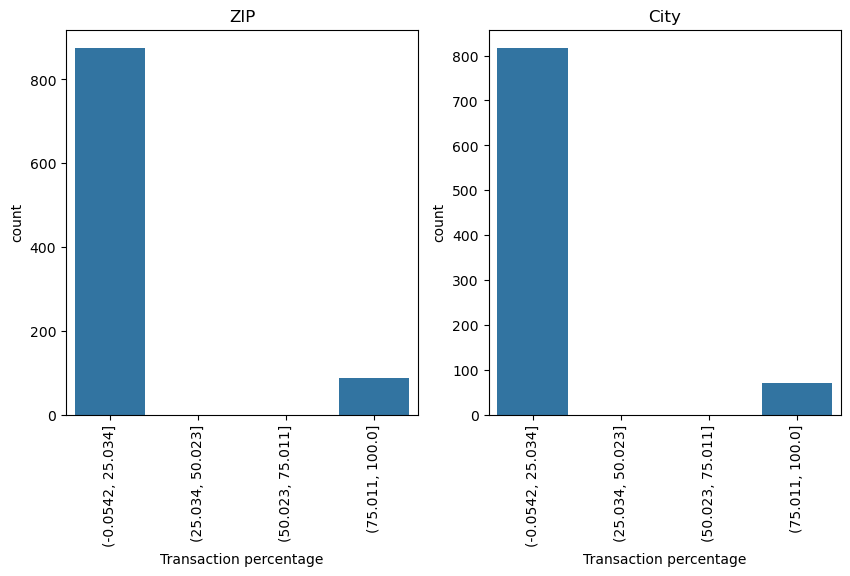

In [58]:
fraud_zip_filtered = df_fraud_zip.loc[df_fraud_zip['is_fraud'] == 1, 'Transaction percentage']
fraud_city_filtered = df_fraud_city.loc[df_fraud_city['is_fraud'] == 1, 'Transaction percentage']
if fraud_zip_filtered.empty or fraud_city_filtered.empty:
    print("Warning: No fraudulent transactions found in one of the datasets!")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.countplot(x=pd.cut(fraud_zip_filtered, bins=4), ax=axes[0])
    sns.countplot(x=pd.cut(fraud_city_filtered, bins=4), ax=axes[1])
    axes[0].set_title('ZIP')
    axes[1].set_title('City')
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

In [59]:
print('Cities with more than 75% fraudulent transactions:\n')
print(df_fraud_city.loc[(df_fraud_city.is_fraud == 1) & (df_fraud_city['Transaction percentage'] >= 75)].city.tolist())
print('\n\nZip codes with more than 75% fraudulent transactions:\n')
print(df_fraud_zip.loc[(df_fraud_zip.is_fraud == 1) & (df_fraud_zip['Transaction percentage'] >= 75)].zip.tolist())

Cities with more than 75% fraudulent transactions:

['Angwin', 'Ashland', 'Beacon', 'Brookfield', 'Bruce', 'Buellton', 'Byesville', 'Chattanooga', 'Clarion', 'Claypool', 'Clinton', 'Coulee Dam', 'Craig', 'Crouse', 'Downey', 'East China', 'Freeport', 'Gaines', 'Granbury', 'Greenport', 'Grenola', 'Grifton', 'Guthrie', 'Hubbell', 'Irvington', 'Isanti', 'Kaktovik', 'Karns City', 'Kirkwood', 'Kirtland', 'La Grande', 'Las Vegas', 'Lexington', 'Lockhart', 'Madisonville', 'Marshall', 'Medford', 'Melville', 'Mineral', 'Morrowville', 'Morven', 'Moss Point', 'Mount Vernon', 'Mountain City', 'Nanuet', 'Nicholson', 'Noblesville', 'Norfolk', 'North East', 'Oakton', 'Orange Park', 'Phelps', 'Pleasant Hill', 'Queen Anne', 'Rice', 'Ridge Spring', 'Roland', 'Seattle', 'Seligman', 'Senatobia', 'Springville', 'Streator', 'Vacaville', 'Walkertown', 'Wappapello', 'Wartburg', 'Waukau', 'West Frankfort', 'Wever', 'Winnsboro']


Zip codes with more than 75% fraudulent transactions:

[4032, 10018, 10533, 10553,

##### **Observation ('city' and 'zip' Features):**
- The plots highlight cities and zip codes with the highest transaction frequencies.
- These areas are among the busiest globally, justifying their high transaction volumes.
- Approximately 50 zip codes and 70 cities have over 75% fraudulent transactions.

##### **Inference:**
- Residents in these areas should be educated about credit card fraud risks and prevention methods.
- Increased transaction monitoring in these regions can help reduce fraudulent activities.

In [61]:
df.job.nunique()

497

- Similar to the 'city' and 'zip' features, the 'job' feature too has a lot of unique values which make it difficult for us to visualize and analyse the feature.
- Therefore, we will now only look at the top 20 jobs, people from which are transacting in high frequencies.

In [63]:
#fetching top 20 jobs with high transaction frequencies
high_trans_jobs = df.job.value_counts().head(20).index.tolist()
print(high_trans_jobs)

['Film/video editor', 'Exhibition designer', 'Surveyor, land/geomatics', 'Naval architect', 'Materials engineer', 'Designer, ceramics/pottery', 'Environmental consultant', 'Financial adviser', 'Systems developer', 'IT trainer', 'Copywriter, advertising', 'Scientist, audiological', 'Chartered public finance accountant', 'Chief Executive Officer', 'Podiatrist', 'Comptroller', 'Magazine features editor', 'Agricultural consultant', 'Paramedic', 'Sub']


In [64]:
df_job = df[['job','trans_num']].groupby(['job']).count().reset_index()
df_job.columns = ['job', 'job_count']
df_fraud_job = df[['job', 'trans_num', 'is_fraud']].groupby(['job','is_fraud']).count().reset_index()
df_fraud_job.columns = ['job', 'is_fraud', 'Transaction count']

df_fraud_job = df_fraud_job.merge(df_job[['job', 'job_count']], how='inner', on='job')

df_fraud_job['Transaction percentage'] = (df_fraud_job['Transaction count']/df_fraud_job['job_count'])*100
df_fraud_job[df_fraud_job['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,job,is_fraud,Transaction count,job_count,Transaction percentage
444,Homeopath,1,11,11,100.0
2,"Accountant, chartered",1,11,11,100.0
393,Forest/woodland manager,1,9,9,100.0
834,Software engineer,1,11,11,100.0
827,Ship broker,1,7,7,100.0
68,Armed forces technical officer,1,8,8,100.0
228,Dancer,1,19,19,100.0
796,Sales promotion account executive,1,14,14,100.0
39,Air traffic controller,1,17,17,100.0
99,Broadcast journalist,1,9,9,100.0


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\1838714985.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


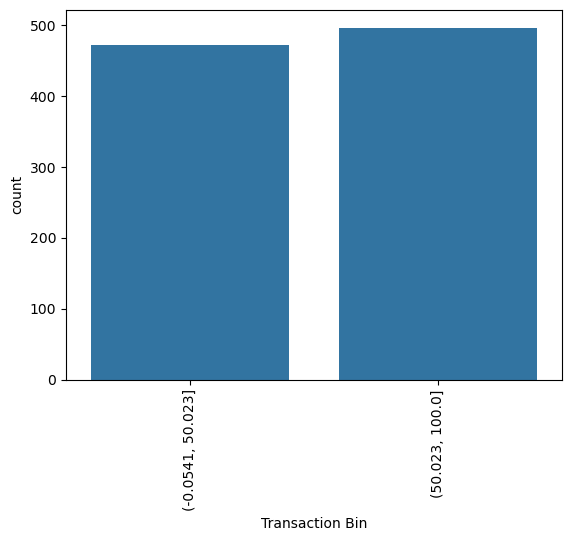

In [65]:
cut_data = pd.cut(df_fraud_job['Transaction percentage'], bins=2)
cut_df = pd.DataFrame({'Transaction Bin': cut_data})
plot = sns.countplot(x='Transaction Bin', data=cut_df)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [66]:
df_fraud_job.loc[(df_fraud_job.is_fraud == 1) & (df_fraud_job['Transaction percentage'] >= 50)].job

2                  Accountant, chartered
39                Air traffic controller
68        Armed forces technical officer
99                  Broadcast journalist
118                      Careers adviser
207           Contracting civil engineer
228                               Dancer
335                       Engineer, site
340                      Engineer, water
393              Forest/woodland manager
444                            Homeopath
475                     Industrial buyer
478                  Information officer
521                      Legal secretary
624        Operational investment banker
651                    Personnel officer
796    Sales promotion account executive
827                          Ship broker
834                    Software engineer
837                            Solicitor
947                   Veterinary surgeon
956                    Warehouse manager
Name: job, dtype: object

##### **Observation ('job' Feature):**
- High transaction frequencies are noted in specific job roles.
- Jobs like Armed Forces Technical Officer, Engineer (Site), Information Officer, Legal Secretary, and others listed have *completely fraudulent transactions*.

##### **Inference:**
- Individuals in jobs with high fraudulent transactions should be alerted and educated about credit card fraud risks to encourage caution.
- The presence of jobs where *all transactions are fraudulent* may indicate data anomalies or potential issues with specific users. Conducting background checks on users in these roles could help identify and address the root cause.

In [68]:
df.category.value_counts(normalize=True)

category
gas_transport     0.101506
grocery_pos       0.095115
home              0.094721
shopping_pos      0.089864
kids_pets         0.087307
shopping_net      0.075212
entertainment     0.072403
food_dining       0.070573
personal_care     0.070225
health_fitness    0.066159
misc_pos          0.061666
misc_net          0.048939
grocery_net       0.035024
travel            0.031287
Name: proportion, dtype: float64

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\3186962843.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


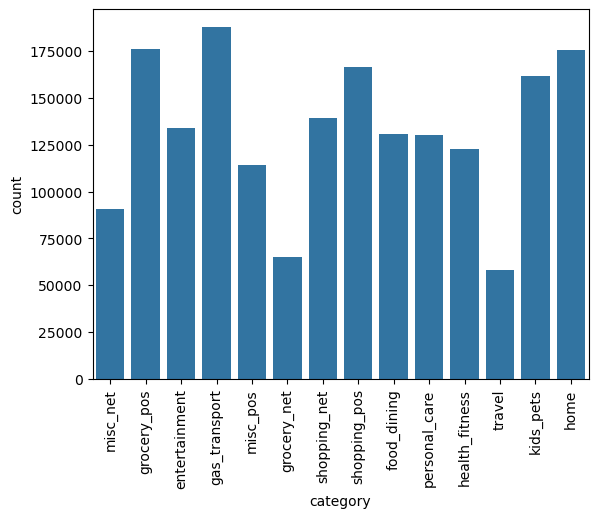

In [69]:
df['category'] = df['category'].astype(str)
plot = sns.countplot(x='category', data=df)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [70]:
df_category = df[['category','trans_num']].groupby(['category']).count().reset_index()
df_category.columns = ['category', 'category_count']

#creating the zip-fraud distribution
df_fraud_category = df[['category', 'trans_num', 'is_fraud']].groupby(['category','is_fraud']).count().reset_index()
df_fraud_category.columns = ['category', 'is_fraud', 'Transaction count']

df_fraud_category = df_fraud_category.merge(df_category[['category', 'category_count']], how='inner', on='category')

df_fraud_category['Transaction percentage'] = (df_fraud_category['Transaction count']/df_fraud_category['category_count'])*100

#viewing the top categories with high fraudulent transaction volumes
df_fraud_category[df_fraud_category['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False)

,category,is_fraud,Transaction count,category_count,Transaction percentage
23,shopping_net,1,2219,139322,1.592713
17,misc_net,1,1182,90654,1.303859
9,grocery_pos,1,2228,176191,1.264537
25,shopping_pos,1,1056,166463,0.634375
5,gas_transport,1,772,188029,0.410575
19,misc_pos,1,322,114229,0.281890
7,grocery_net,1,175,64878,0.269737
27,travel,1,156,57956,0.269170
21,personal_care,1,290,130085,0.222931
1,entertainment,1,292,134118,0.217719


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2866042641.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


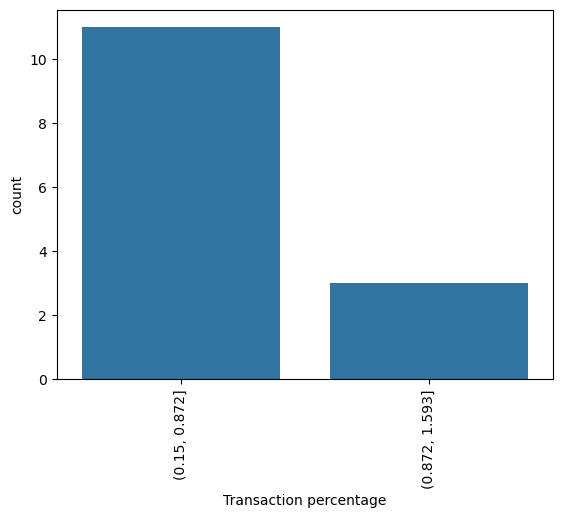

In [71]:
fraud_data = df_fraud_category[df_fraud_category.is_fraud == 1]['Transaction percentage']
if fraud_data.empty:
    print("Error: No fraudulent transactions found!")
else:
    fraud_bins = pd.cut(fraud_data, bins=2)
   
    fraud_bins = fraud_bins.astype(str)
    plot = sns.countplot(x=fraud_bins)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
    plt.show()

In [72]:
df_fraud_category.loc[(df_fraud_category.is_fraud == 1) & (df_fraud_category['Transaction percentage'] >= 1)].category

9      grocery_pos
17        misc_net
23    shopping_net
Name: category, dtype: object

In [73]:
df_fraud_category.head()

,category,is_fraud,Transaction count,category_count,Transaction percentage
0,entertainment,0,133826,134118,99.782281
1,entertainment,1,292,134118,0.217719
2,food_dining,0,130524,130729,99.843187
3,food_dining,1,205,130729,0.156813
4,gas_transport,0,187257,188029,99.589425


#### **Observation ('category' Feature):**
- Three categories—grocery_pos, misc_net, and shopping_net—have over 1% fraudulent transactions, with shopping_net having the highest number of fraud cases.

#### **Inference:**
- The shopping_net category is particularly vulnerable to fraud, possibly due to compromised transaction systems or mechanisms used by fraudsters.
- These categories (grocery_pos, misc_net, shopping_net) should be thoroughly investigated and monitored to reduce fraudulent activities and improve transaction security.

In [75]:
df.merchant.nunique()

693

In [76]:
high_trans_merchants = df.merchant.value_counts().head(20).index.tolist()
high_trans_merchants

['fraud_Kilback LLC',
 'fraud_Cormier LLC',
 'fraud_Schumm PLC',
 'fraud_Kuhn LLC',
 'fraud_Boyer PLC',
 'fraud_Dickinson Ltd',
 'fraud_Emard Inc',
 'fraud_Cummerata-Jones',
 'fraud_Corwin-Collins',
 'fraud_Rodriguez Group',
 'fraud_Kling Inc',
 'fraud_Parisian and Sons',
 'fraud_Erdman-Kertzmann',
 'fraud_Huels-Hahn',
 'fraud_Stroman, Hudson and Erdman',
 'fraud_Kutch LLC',
 'fraud_Jenkins, Hauck and Friesen',
 'fraud_Prohaska-Murray',
 'fraud_Olson, Becker and Koch',
 'fraud_Eichmann, Bogan and Rodriguez']

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\204432241.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


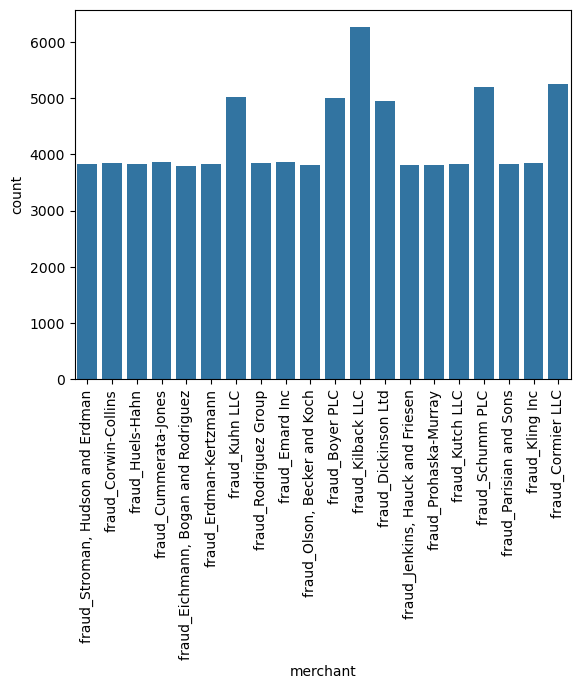

In [77]:
filtered_df = df[df.merchant.isin(high_trans_merchants)]
plot = sns.countplot(x=filtered_df.merchant)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [78]:
df_merchant = df[['merchant','trans_num']].groupby(['merchant']).count().reset_index()
df_merchant.columns = ['merchant', 'merchant_count']
df_fraud_merchant = df[['merchant', 'trans_num', 'is_fraud']].groupby(['merchant','is_fraud']).count().reset_index()
df_fraud_merchant.columns = ['merchant', 'is_fraud', 'Transaction count']

df_fraud_merchant = df_fraud_merchant.merge(df_merchant[['merchant', 'merchant_count']], how='inner', on='merchant')

df_fraud_merchant['Transaction percentage'] = (df_fraud_merchant['Transaction count']/df_fraud_merchant['merchant_count'])*100
df_fraud_merchant[df_fraud_merchant['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,merchant,is_fraud,Transaction count,merchant_count,Transaction percentage
673,fraud_Kozey-Boehm,1,60,2758,2.175489
490,"fraud_Herman, Treutel and Dickens",1,38,1870,2.032086
1226,fraud_Terry-Huel,1,56,2864,1.955307
607,fraud_Kerluke-Abshire,1,50,2635,1.897533
884,"fraud_Mosciski, Ziemann and Farrell",1,53,2821,1.878766
1105,"fraud_Schmeler, Bashirian and Price",1,52,2788,1.865136
691,fraud_Kuhic LLC,1,53,2842,1.864884
563,fraud_Jast Ltd,1,51,2757,1.849837
743,"fraud_Langworth, Boehm and Gulgowski",1,52,2817,1.845935
1051,"fraud_Romaguera, Cruickshank and Greenholt",1,51,2767,1.843151


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_10160\2938568713.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)


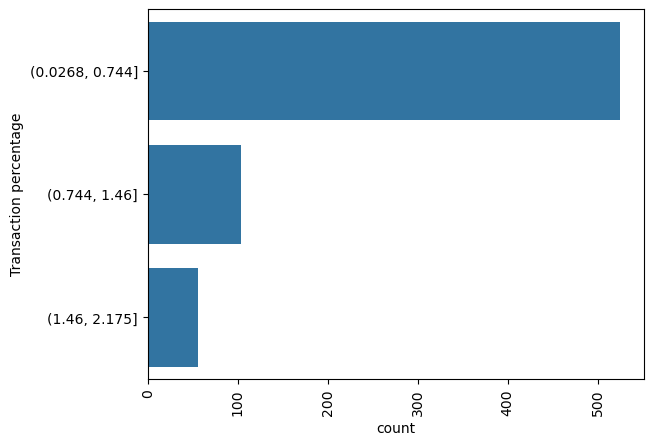

In [176]:
plot = sns.countplot(pd.cut(df_fraud_merchant[df_fraud_merchant.is_fraud == 1]['Transaction percentage'], bins = 3))
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)
plt.show()

In [80]:
len(df_fraud_merchant.loc[(df_fraud_merchant.is_fraud == 1) & (df_fraud_merchant['Transaction percentage'] >= 1)].merchant)

139

In [81]:
df_fraud_merchant.loc[(df_fraud_merchant.is_fraud == 1) & (df_fraud_merchant['Transaction percentage'] >= 2)].merchant

490    fraud_Herman, Treutel and Dickens
673                    fraud_Kozey-Boehm
Name: merchant, dtype: object

##### **Observation ('merchant' Feature):**
- About 140 merchants have over 1% of their transactions flagged as fraudulent.
- Top merchants with the highest fraudulent transactions include fraud_Brown PLC, fraud_Goyette Inc, fraud_Herman, Treutel and Dickens, fraud_Jast Ltd, fraud_Kerluke-Abshire, fraud_Kozey-Boehm, fraud_Schmeler, Bashirian and Price, and fraud_Terry-Huel.

##### **Inference:**
- These merchants should be investigated for potential fraudulent practices.
- They should also be alerted and educated on how to identify and prevent fraudulent activities to improve transaction security.

# **Step - 4: Feature Encoding**

In [178]:
category_onehot = pd.get_dummies(df.category, prefix='category', drop_first=True).astype(int)
gender_onehot = pd.get_dummies(df.gender, prefix='gender', drop_first=True).astype(int)
day_of_week_onehot = pd.get_dummies(df.trans_day_of_week, prefix='day', drop_first=True).astype(int)
age_onehot = pd.get_dummies(df.age, prefix='age', drop_first=True).astype(int)

In [180]:
df1 = pd.concat([df, category_onehot,gender_onehot,day_of_week_onehot,age_onehot], axis=1)
df1.head()

,Unnamed: 0,cc_num,merchant,category,amt,gender,street,city,state,zip,...,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,age_46-60,age_61-75,age_< 30,age_> 75
0,0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,0,0,0,0,1,0,0,0,0,0
1,1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,0,0,0,0,1,0,0,0,0,0
2,2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,0,0,0,0,1,0,1,0,0,0
3,3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,0,0,0,0,1,0,1,0,0,0
4,4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,0,0,0,0,1,0,0,0,0,0


In [182]:
df1.drop([ 'cc_num', 'trans_num'], axis=1, inplace=True)
print(df1.shape)
df1.columns

(1852394, 45)


Index(['Unnamed: 0', 'merchant', 'category', 'amt', 'gender', 'street', 'city',
       'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'trans_hour',
       'trans_day_of_week', 'trans_year_month', 'age', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'gender_M', 'day_Monday',
       'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday',
       'day_Wednesday', 'age_46-60', 'age_61-75', 'age_< 30', 'age_> 75'],
      dtype='object')

In [184]:
df1.drop(['merchant','street','city','state','job',
          'category','gender','trans_day_of_week',
          'age'],axis=1, inplace=True)
df1.columns

Index(['Unnamed: 0', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'trans_hour', 'trans_year_month',
       'category_food_dining', 'category_gas_transport',
       'category_grocery_net', 'category_grocery_pos',
       'category_health_fitness', 'category_home', 'category_kids_pets',
       'category_misc_net', 'category_misc_pos', 'category_personal_care',
       'category_shopping_net', 'category_shopping_pos', 'category_travel',
       'gender_M', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday',
       'day_Tuesday', 'day_Wednesday', 'age_46-60', 'age_61-75', 'age_< 30',
       'age_> 75'],
      dtype='object')

- Now, some features like 'cc_num', 'first', 'last', 'trans_num' are not significant in context of our analysis and hence can be removed.
- In the df1 DataFrame, the **'merchant'** feature can be dropped due to its high number of unique values, making it difficult to encode effectively. The same applies to the variables **'street'**, **'city'**, **'state'**, and **'job'**.
- Additionally, the variables **'age'**, **'category'**, **'gender'**, and **'trans_day_of_week'** can also be dropped as they have already been encoded and their information is preserved in the dataset.

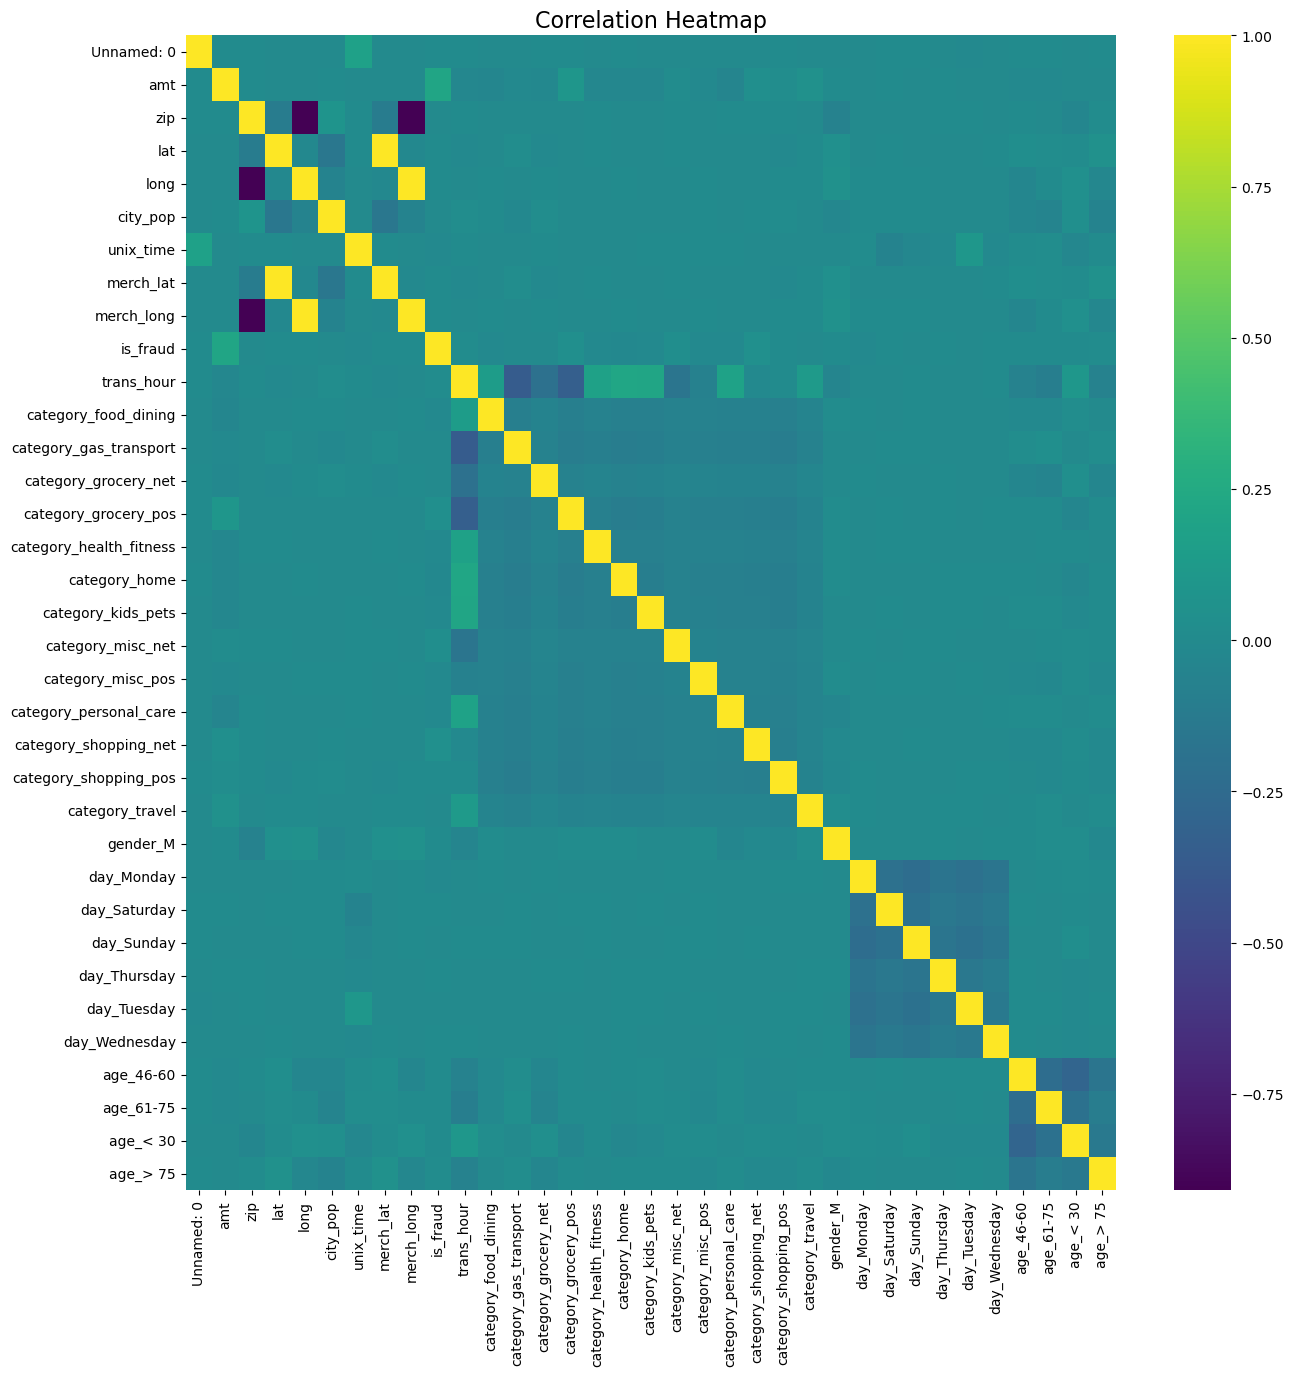

In [198]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_random_under_corr, cmap="viridis")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


In [200]:
def correlation(dataset, threshold):
    col_corr = set() 
    corr_matrix = dataset.corr() 
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j] > threshold:
                colname = corr_matrix.columns[i] #selecting columns above threshold
                col_corr.add(colname) #adding columns to set
    return col_corr

In [202]:
df_numeric = df1.select_dtypes(include=['number']) 
corr_features = correlation(df_numeric,0.85)
corr_features

{'merch_lat', 'merch_long'}

- As it can be seen, there are no features that have a correlation of above 85% apart from merchant lat and long. Hence, it is safe to proceed with out model building.

# **Step - 5: Implementing Algorithms**